# Batch Depth Map Processing with Depth Anything V2

This notebook processes all images from `data/images_rect/images_rect/image_0/` and generates depth maps saved to `data/depth_image_0/`.

## 1. Setup and Imports

In [2]:
# Check and optimize CUDA memory settings
import os
import torch

# Set CUDA memory allocation configuration
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print("CUDA Memory Configuration:")
print(f"  PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF', 'Not set')}")

if torch.cuda.is_available():
    print(f"\nGPU Memory Status:")
    print(f"  Total memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"  Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"  Cached: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
    torch.cuda.empty_cache()
    print(f"  After cache clear - Cached: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

CUDA Memory Configuration:
  PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True

GPU Memory Status:
  Total memory: 7.53 GB
  Allocated: 0.00 GB
  Cached: 0.00 GB
  After cache clear - Cached: 0.00 GB


In [3]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import os
import sys

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5050 Laptop GPU


## 2. Clone and Setup Depth Anything V2

In [4]:
# Clone the Depth Anything V2 repository if not exists
if not os.path.exists('Depth-Anything-V2'):
    !git clone https://github.com/DepthAnything/Depth-Anything-V2.git
    print("Repository cloned successfully!")
else:
    print("Repository already exists!")

# Change to the metric depth directory
os.chdir('Depth-Anything-V2/metric_depth')
sys.path.insert(0, os.getcwd())
print(f"Current directory: {os.getcwd()}")

Repository already exists!
Current directory: /workspace/notebooks/Depth-Anything-V2/metric_depth


In [5]:
# Import the model
from depth_anything_v2.dpt import DepthAnythingV2

xFormers not available
xFormers not available


## 3. Configure Paths

In [6]:
# Input and output paths
input_dir = Path('/workspace/data/images_rect/images_rect/image_0')
output_dir = Path('/workspace/data/depth_image_0')

# Create output directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

# Get list of all images
image_files = sorted(list(input_dir.glob('*.png')))
print(f"Found {len(image_files)} images to process")
print(f"Input directory: {input_dir}")
print(f"Output directory: {output_dir}")

# Show first few files
print("\nFirst 5 images:")
for img_file in image_files[:5]:
    print(f"  - {img_file.name}")

Found 363 images to process
Input directory: /workspace/data/images_rect/images_rect/image_0
Output directory: /workspace/data/depth_image_0

First 5 images:
  - 000000.png
  - 000001.png
  - 000002.png
  - 000003.png
  - 000004.png


## 4. Load the Depth Anything V2 Model

In [7]:
# Model configuration
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

# Configuration for VKITTI (outdoor scenes)
encoder = 'vitl'  # Large model
dataset = 'vkitti'  # Outdoor scenes
max_depth = 80  # Maximum depth in meters for outdoor scenes

# Path to the model checkpoint
model_path = '/workspace/models/depth_anything_v2_metric_vkitti_vitl.pth'

print(f"Loading model: {encoder} trained on {dataset}")
print(f"Max depth: {max_depth} meters")

# Initialize the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = DepthAnythingV2(**{**model_configs[encoder], 'max_depth': max_depth})
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("✓ Model loaded successfully!")

Loading model: vitl trained on vkitti
Max depth: 80 meters
Using device: cuda
✓ Model loaded successfully!


## 5. Process All Images

In [8]:
# Process all images
print(f"\nProcessing {len(image_files)} images...\n")

with torch.no_grad():
    for img_path in tqdm(image_files, desc="Processing images"):
        try:
            # Read image
            raw_img = cv2.imread(str(img_path))
            
            if raw_img is None:
                print(f"\nWarning: Could not read {img_path.name}")
                continue
            
            # Run inference
            depth = model.infer_image(raw_img)  # Returns depth in meters
            
            # Save depth map as numpy array (.npy)
            output_path_npy = output_dir / f"{img_path.stem}.npy"
            np.save(output_path_npy, depth)
            
            # Optionally save visualization as PNG
            # Normalize depth to 0-255 for visualization
            depth_normalized = (depth - depth.min()) / (depth.max() - depth.min())
            depth_colored = plt.cm.inferno(depth_normalized)[:, :, :3]  # Remove alpha
            depth_colored = (depth_colored * 255).astype(np.uint8)
            
            output_path_png = output_dir / f"{img_path.stem}_depth.png"
            cv2.imwrite(str(output_path_png), cv2.cvtColor(depth_colored, cv2.COLOR_RGB2BGR))
            
        except Exception as e:
            print(f"\nError processing {img_path.name}: {str(e)}")
            continue

print("\n✓ Processing complete!")
print(f"Results saved to: {output_dir}")


Processing 363 images...



Processing images: 100%|██████████| 363/363 [05:22<00:00,  1.12it/s]


✓ Processing complete!
Results saved to: /workspace/data/depth_image_0


## 6. Verify Results

In [9]:
# Count output files
npy_files = list(output_dir.glob('*.npy'))
png_files = list(output_dir.glob('*_depth.png'))

print(f"Total depth maps saved: {len(npy_files)} (.npy files)")
print(f"Total visualizations saved: {len(png_files)} (.png files)")
print(f"\nOutput directory: {output_dir}")

Total depth maps saved: 363 (.npy files)
Total visualizations saved: 363 (.png files)

Output directory: /workspace/data/depth_image_0


## 7. Visualize Sample Results

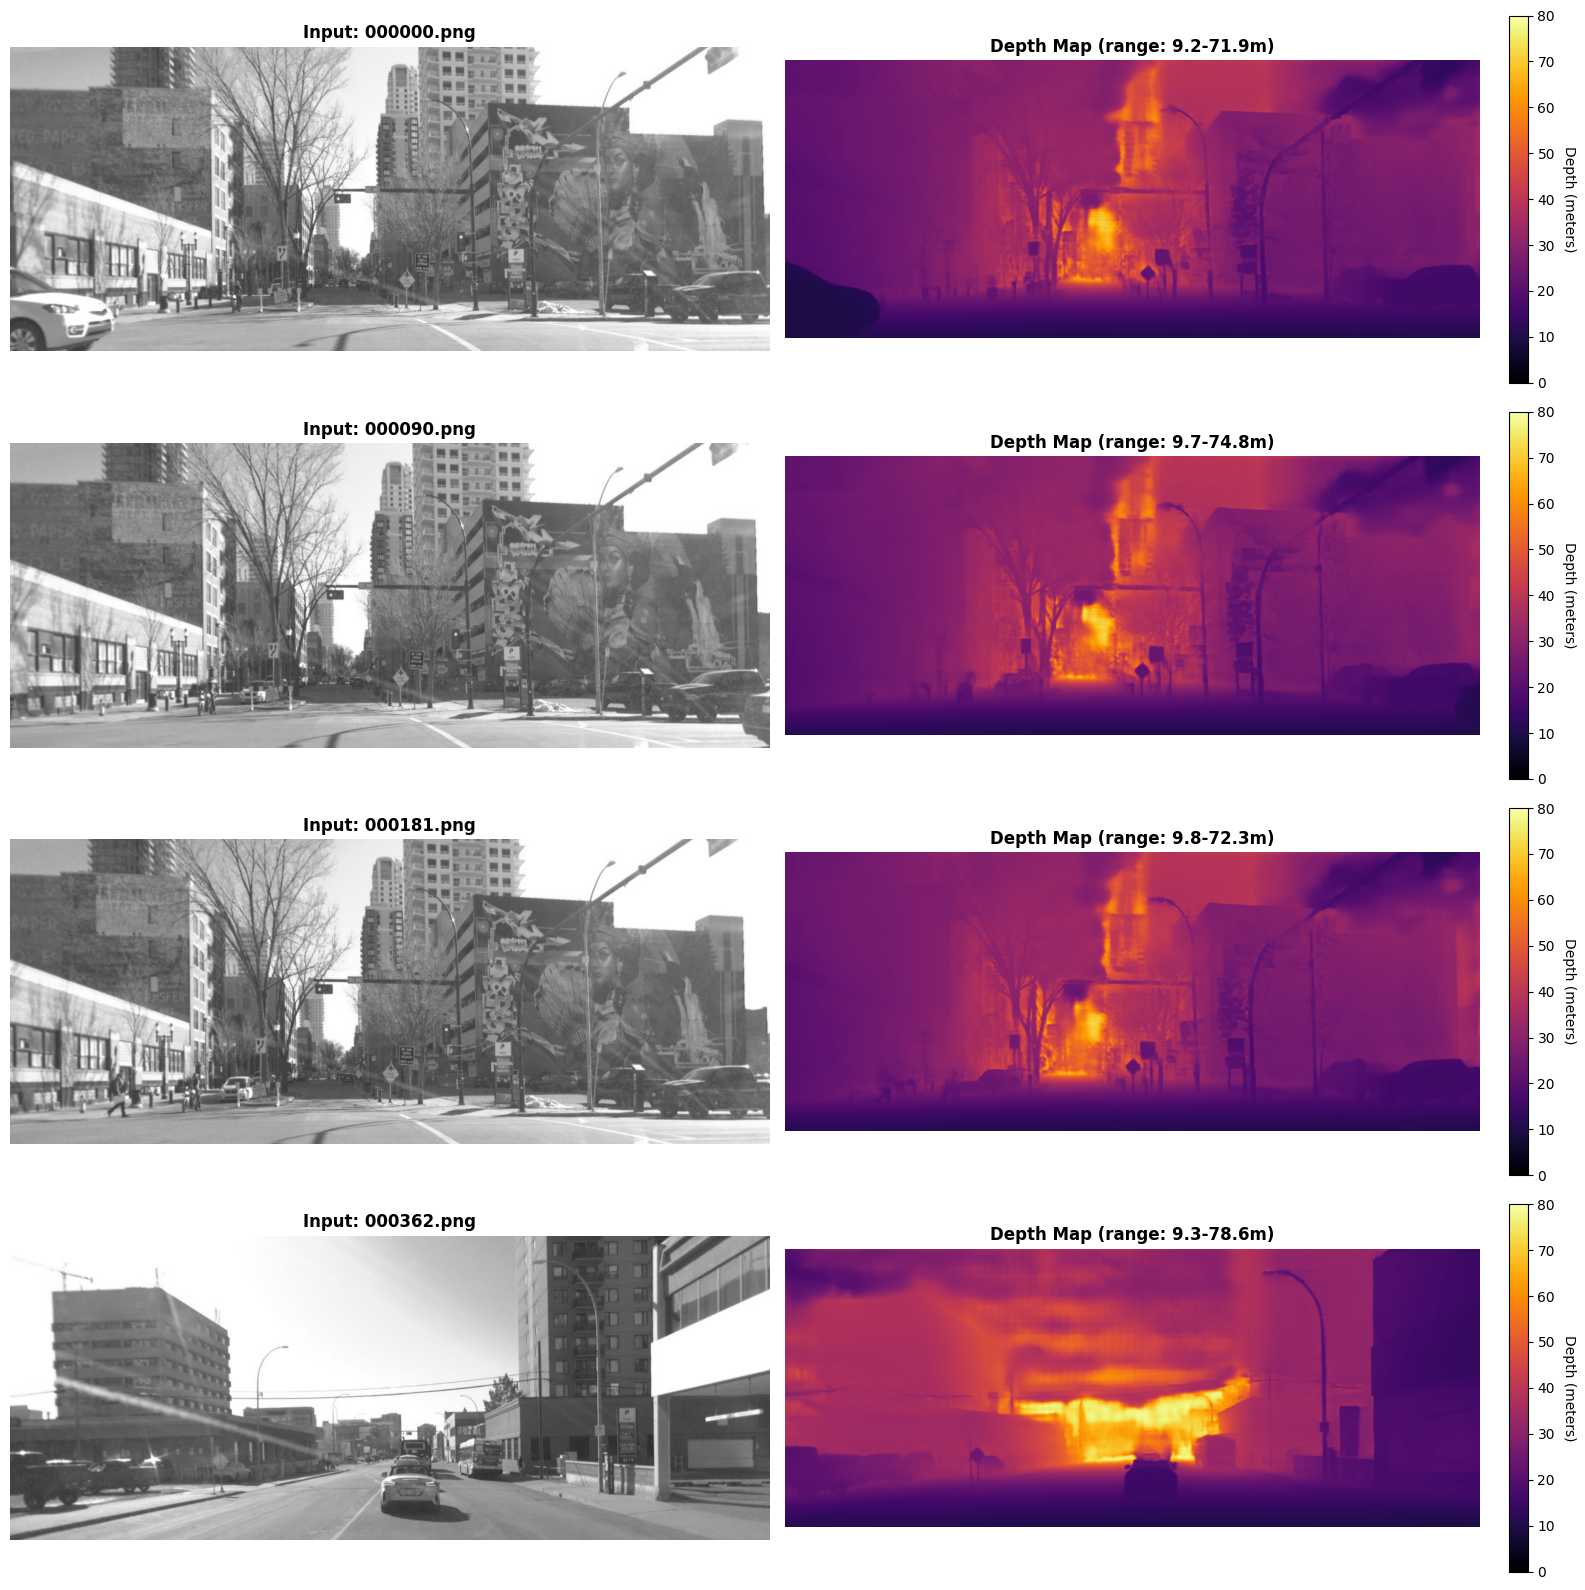

Sample visualizations shown above.


In [10]:
# Visualize a few sample results
sample_indices = [0, len(image_files)//4, len(image_files)//2, -1]  # First, 25%, 50%, last

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(16, 4*len(sample_indices)))

for idx, img_idx in enumerate(sample_indices):
    img_path = image_files[img_idx]
    depth_path = output_dir / f"{img_path.stem}.npy"
    
    # Load image and depth
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    depth = np.load(depth_path)
    
    # Plot
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'Input: {img_path.name}', fontsize=12, fontweight='bold')
    axes[idx, 0].axis('off')
    
    im = axes[idx, 1].imshow(depth, cmap='inferno', vmin=0, vmax=max_depth)
    axes[idx, 1].set_title(f'Depth Map (range: {depth.min():.1f}-{depth.max():.1f}m)', 
                           fontsize=12, fontweight='bold')
    axes[idx, 1].axis('off')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[idx, 1], fraction=0.046, pad=0.04)
    cbar.set_label('Depth (meters)', rotation=270, labelpad=15, fontsize=10)

plt.tight_layout()
plt.show()

print("Sample visualizations shown above.")

## 8. Depth Statistics Summary

In [ ]:
# Analyze depth statistics across all images
print("Computing statistics across all depth maps...\n")

all_min_depths = []
all_max_depths = []
all_mean_depths = []

for npy_file in tqdm(npy_files, desc="Analyzing depth maps"):
    depth = np.load(npy_file)
    all_min_depths.append(depth.min())
    all_max_depths.append(depth.max())
    all_mean_depths.append(depth.mean())

print("\n" + "="*50)
print("DEPTH STATISTICS SUMMARY")
print("="*50)
print(f"Number of images processed: {len(npy_files)}")
print(f"\nMinimum depths:")
print(f"  Overall min: {np.min(all_min_depths):.2f}m")
print(f"  Average min: {np.mean(all_min_depths):.2f}m")
print(f"\nMaximum depths:")
print(f"  Overall max: {np.max(all_max_depths):.2f}m")
print(f"  Average max: {np.mean(all_max_depths):.2f}m")
print(f"\nMean depths:")
print(f"  Average: {np.mean(all_mean_depths):.2f}m")
print(f"  Std dev: {np.std(all_mean_depths):.2f}m")
print("="*50)

# Plot histogram of mean depths
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(all_min_depths, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Minimum Depth (m)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Min Depths', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(all_mean_depths, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Mean Depth (m)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Mean Depths', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(all_max_depths, bins=30, color='coral', alpha=0.7, edgecolor='black')
plt.xlabel('Maximum Depth (m)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Max Depths', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook has:
- ✅ Processed all images from `data/images_rect/images_rect/image_0/`
- ✅ Generated metric depth maps using Depth Anything V2 (VKITTI model)
- ✅ Saved depth maps as `.npy` files (raw metric values in meters)
- ✅ Saved visualizations as `.png` files with inferno colormap
- ✅ All outputs saved to `data/depth_image_0/`

**Output Files:**
- `*.npy` - NumPy arrays with metric depth in meters (HxW)
- `*_depth.png` - Visualization images for quick inspection

In [11]:
import shutil
shutil.make_archive('nodelab-deep-anything', 'zip', '/workspace/data/depth_image_0')


'/workspace/notebooks/Depth-Anything-V2/metric_depth/nodelab-deep-anything.zip'